**Q1 - Materials Project data (38 points)<br>**
Using pymatgen (or any alternative approach), query the Materials Project for the following properties of all ABO3 type compounds:

- materials project identifier (material_id) <br>
- formula of the compound<br>
- number of sites in the unit cell<br>
- band gap<br>
- formation energy per atom<br>
- theoretical (indicates whether a material is a theoretically generated one.)<br>
- energy above hull

1. Perform the query and convert the data into a Pandas DataFrame. (10 points)

In [1]:
# -*- coding: utf-8 -*-
# pip install pymatgen 
# pip install mp-api
# pmg config --add PMG_MAPI_KEY <KEY_OBTAINED_FROM_MP>
# The above command already set in the NANOx81 environment through terminal 


#1st step: Perform a search for ABO3 in the Materials Project database and query for required fields
from mp_api.client import MPRester
import pandas as pd

requested = ["material_id",
            "formula_pretty",
            "nsites",
            "band_gap",
            "formation_energy_per_atom",
            "theoretical",
            "energy_above_hull",
            ]
with MPRester() as mpr:
    data = mpr.materials.summary.search(formula=["**O3"], fields= requested, all_fields=False)

#2nd step: Convert the data to a pandas DataFrame and filter for desired columns 

dict_list = []
for d in data:
    dict_ = {}
    dict_["material_id"] = d.material_id
    dict_["formula_pretty"] = d.formula_pretty
    dict_["nsites"] = d.nsites
    dict_["band_gap"] = d.band_gap
    dict_["formation_energy_per_atom"] = d.formation_energy_per_atom
    dict_["theoretical"] = d.theoretical
    dict_["energy_above_hull"] = d.energy_above_hull
    dict_list.append(dict_)
df_abo3 = pd.DataFrame(dict_list)
df_abo3


Retrieving SummaryDoc documents:   0%|          | 0/2547 [00:00<?, ?it/s]

,material_id,formula_pretty,nsites,band_gap,formation_energy_per_atom,theoretical,energy_above_hull
0,mp-1101047,TiCdO3,10,0.0000,-1.556926,True,1.114535
1,mp-1173585,NaNO3,20,2.7742,-1.350257,True,0.012940
2,mp-1179315,SrTeO3,120,3.2315,-2.377819,True,0.003206
3,mp-1178894,VHO3,20,0.0094,-1.922323,True,0.063993
4,mp-1180213,NaBrO3,20,0.0000,-0.299051,True,0.700011
...,...,...,...,...,...,...,...
2542,mp-760376,KTiO3,5,0.0000,-2.662460,True,0.089448
2543,mp-5986,BaTiO3,5,1.7280,-3.490321,False,0.001957
2544,mp-545522,CoBiO3,5,0.0000,-1.458913,False,0.000000
2545,mp-4342,KNbO3,5,1.4760,-2.850938,False,0.001190


2. How many ABO3 compounds in total are there in the Materials Project? How many unique ABO3 formula are there? What is the average number of crystals (also known as polymorphs) per ABO3 formula? (6 points)

In [2]:
#Q1 How many ABO3 compounds in total
total_abo3=len(df_abo3)
print (f"Total ABO3 compounds: {total_abo3}")



#Q2 How many unique ABO3 formula are there?
unique_abo3=len(df_abo3['formula_pretty'].unique())
print (f"Unique ABO3 formula: {unique_abo3}")


#Q3 What is the average number of crystals per ABO3 formula?
# Group by formula and count how many times each appears
polymorph_counts = df_abo3["formula_pretty"].value_counts()
# Compute the average number of polymorphs per formula
average_polymorphs = polymorph_counts.mean()
print(f"Average number of polymorphs per ABO3 formula: {average_polymorphs:.2f}")


Total ABO3 compounds: 2547
Unique ABO3 formula: 1318
Average number of polymorphs per ABO3 formula: 1.93


3. What fraction of the compounds are non-theoretical? (2 points)


In [3]:
theoretical_count = len(df_abo3[df_abo3["theoretical"] == True])
non_theoretical_count = len(df_abo3[df_abo3["theoretical"] == False])
fraction_theoretical = theoretical_count / total_abo3
fraction_non_theoretical = non_theoretical_count / total_abo3

print(f"Number of theoretical ABO3 compounds: {theoretical_count}")
print(f"Number of non-theoretical ABO3 compounds: {non_theoretical_count}")

print(f"Fraction of theoretical ABO3 compounds: {fraction_theoretical:.2%}")
print(f"Fraction of non-theoretical ABO3 compounds: {fraction_non_theoretical:.2%}")

Number of theoretical ABO3 compounds: 1716
Number of non-theoretical ABO3 compounds: 831
Fraction of theoretical ABO3 compounds: 67.37%
Fraction of non-theoretical ABO3 compounds: 32.63%


4. The formation energies in the Materials Project are given in eV/atom. Create an additional column in your dataset that has the formation energies in J/mol. (4 points)

In [4]:
df_abo3["formation_energy_per_atom_Joules"] = df_abo3["formation_energy_per_atom"] * 1.60218e-19
df_abo3.head(5)

,material_id,formula_pretty,nsites,band_gap,formation_energy_per_atom,theoretical,energy_above_hull,formation_energy_per_atom_Joules
0,mp-1101047,TiCdO3,10,0.0000,-1.556926,True,1.114535,-2.494475e-19
1,mp-1173585,NaNO3,20,2.7742,-1.350257,True,0.012940,-2.163355e-19
2,mp-1179315,SrTeO3,120,3.2315,-2.377819,True,0.003206,-3.809694e-19
3,mp-1178894,VHO3,20,0.0094,-1.922323,True,0.063993,-3.079908e-19
4,mp-1180213,NaBrO3,20,0.0000,-0.299051,True,0.700011,-4.791333e-20


5. Let us assume that materials with energy above hull of >0.03 eV/atom are unstable and are potentially stable otherwise. Furthermore, band gaps (E_g) of E_g = 0, 0 < E_g ≤ 1, E_g > 1 are indicative of metallic, small band gap, large band gap for the materials. Create a table of the number of ABO3 crystals in each joint category, e.g., (unstable, metallic), (unstable, small band gap), etc. (10 points)


In [5]:
def classify_stability(e):
    return "unstable" if e > 0.03 else "stable"

def classify_bandgap(bg):
    if bg == 0:
        return "metallic"
    elif bg <= 1:
        return "small_band_gap"
    else:
        return "large_band_gap"

# Add new classification columns
df_abo3["stability"] = df_abo3["energy_above_hull"].apply(classify_stability)
df_abo3["bandgap_category"] = df_abo3["band_gap"].apply(classify_bandgap)

# Create pivot-style count table
category_table = pd.crosstab(df_abo3["stability"], df_abo3["bandgap_category"])

category_table

bandgap_category,large_band_gap,metallic,small_band_gap
stability,,,
stable,514,177,99
unstable,480,1056,221


6. Plot the distribution of (a) the formation energies per atom (in eV/atom) and (b) the band gaps of all the materials. Annotate the plots with the average and standard deviation of each quantity. Ensure that all axes are labelled appropriately with units, i.e., something that you6 can potentially put in a scientific paper. (6 points)

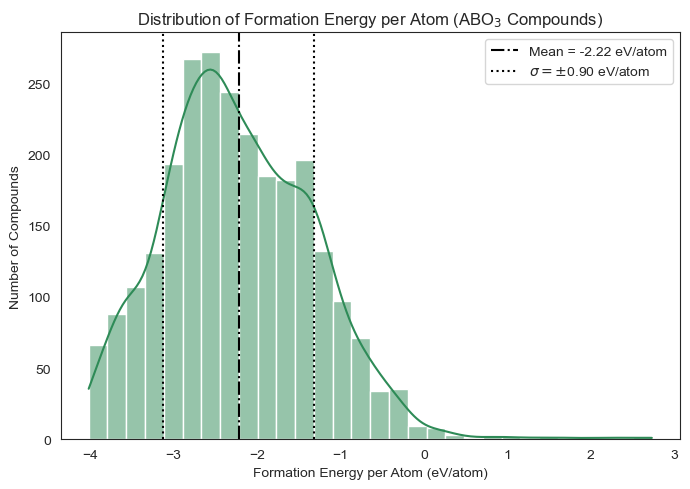

In [6]:
#1st step: Plot the distribution of formation energy per atom

# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
# Set the style of seaborn
sns.set_style(style="white")

# Set the figure size
plt.figure(figsize=(7, 5))
sns.histplot(df_abo3["formation_energy_per_atom"], bins=30, kde=True, color="seagreen")

# Annotations
mean_fe = df_abo3["formation_energy_per_atom"].mean()
std_fe = df_abo3["formation_energy_per_atom"].std()

plt.axvline(mean_fe, color='black', linestyle='-.', label=f"Mean = {mean_fe:.2f} eV/atom")
plt.axvline(mean_fe + std_fe, color='black', linestyle=':', label=f"$  \sigma = \pm ${std_fe:.2f} eV/atom")
plt.axvline(mean_fe - std_fe, color='black', linestyle=':')

plt.xlabel("Formation Energy per Atom (eV/atom)")
plt.ylabel("Number of Compounds")
plt.title("Distribution of Formation Energy per Atom (ABO$_3$ Compounds)")
plt.legend()
plt.tight_layout()
plt.show()

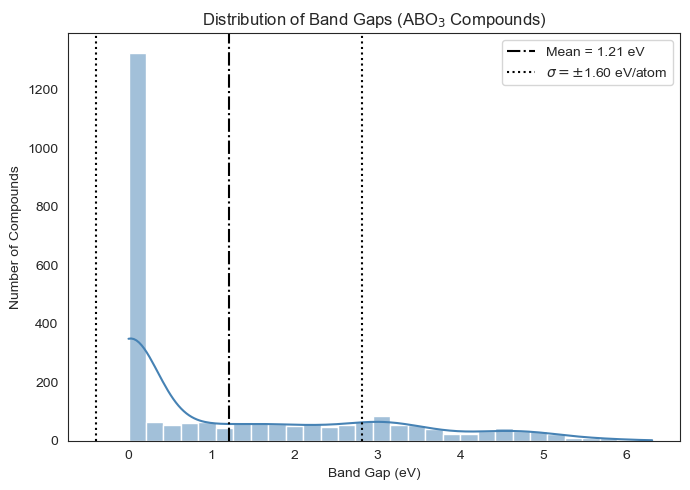

In [7]:
# Step 2: Plot the distribution of band gaps

# Set the style of seaborn
sns.set_style(style="white")
# Set the figure size
plt.figure(figsize=(7, 5))
sns.histplot(df_abo3["band_gap"], bins=30, kde=True, color="steelblue")

# Annotations
mean_bg = df_abo3["band_gap"].mean()
std_bg = df_abo3["band_gap"].std()

plt.axvline(mean_bg, color='black', linestyle='-.', label=f"Mean = {mean_bg:.2f} eV")
plt.axvline(mean_bg + std_bg, color='black', linestyle=':', label=f"$  \sigma = \pm ${std_bg:.2f} eV/atom")
plt.axvline(mean_bg - std_bg, color='black', linestyle=':')

plt.xlabel("Band Gap (eV)")
plt.ylabel("Number of Compounds")
plt.title("Distribution of Band Gaps (ABO$_3$ Compounds)")
plt.legend()
plt.tight_layout()
plt.show()

**Q2 - Publicly available research data (30 points)**
Researchers frequently share the datasets they have via various online platforms. Figshare is one such online platform. We will use this example to illustrate some of the challenges in working with datasets.

1. Query for the data from https://ndownloader.figshare.com/files/9158587, which is in the csv format. This is a dataset of from high-throughput DFT calculations of formation energy, stability and oxygen vacancy formation energy of ABO3 perovskites (https://www.nature.com/articles/sdata2017153) available in the Open Quantum Materials Database (OQMD). This dataset, which we will call the OQMD dataset, comprises computed data on compounds known as perovskites. Parse the data into a Pandas DataFrame. (10 points)
2. How many compounds in total are there? (2 points)
3. How many total columns are there in the dataset? Print the column names. (2 points)
4. Unfortunately, the dataset contains invalid data and some of the data are also not properly tagged in the right data type. For example, the formation energy column contains strings, rather than floating point numbers. There are also strings that indicate whether a particular data point is valid. Filter the DataFrame to remove all invalid data points, i.e., those that contain just “-“ in the formation energy column. and convert the formation energy column to the proper floats. How many data points remain? (10 points)
5. Plot the distribution of the formation energies per atom. Annotate the plot with the average and standard deviation. (6 points)

1. Query for the data from https://ndownloader.figshare.com/files/9158587, which is in the csv format. This is a dataset of from high-throughput DFT calculations of formation energy, stability and oxygen vacancy formation energy of ABO3 perovskites (https://www.nature.com/articles/sdata2017153) available in the Open Quantum Materials Database (OQMD). This dataset, which we will call the OQMD dataset, comprises computed data on compounds known as perovskites. Parse the data into a Pandas DataFrame. (10 points)

In [8]:
#1. Importing the OQMD dataset and parsing it into a DataFrame
import pandas as pd

url = "https://ndownloader.figshare.com/files/9158587"
df_oqmd = pd.read_csv(url)
df_oqmd.head(5)

,Chemical formula,A,B,In literature,Valence A,Valence B,Radius A [ang],Radius B [ang],Lowest distortion,Formation energy [eV/atom],...,Magnetic moment [mu_B],Volume per atom [A^3/atom],Band gap [eV],a [ang],b [ang],c [ang],alpha [deg],beta [deg],gamma [deg],Vacancy energy [eV/O atom]
0,Ac2O3,Ac,Ac,False,element not in BV,element not in BV,1.12,1.12,cubic,-2.732,...,0.000,20.836,0.332,4.705,4.705,4.705,90.0,90.0,90.0,3.150
1,AcAgO3,Ac,Ag,False,element not in BV,element not in BV,1.12,0.95,orthorhombic,-1.957,...,0.000,14.485,0.000,5.779,6.077,8.248,90.0,90.0,90.0,0.817
2,AcAlO3,Ac,Al,False,element not in BV,element not in BV,1.12,0.54,cubic,-3.532,...,0.000,11.487,4.307,3.858,3.858,3.858,90.0,90.0,90.0,6.695
3,AcAsO3,Ac,As,False,element not in BV,element not in BV,1.12,0.52,orthorhombic,-2.398,...,0.000,14.355,0.000,5.780,6.012,8.262,90.0,90.0,90.0,3.634
4,AcAuO3,Ac,Au,False,element not in BV,element not in BV,1.12,0.93,orthorhombic,-2.006,...,0.000,15.190,0.745,5.899,6.750,7.630,90.0,90.0,90.0,0.807


2. How many compounds in total are there? (2 points)

In [9]:
#2. How many compounds in total are there in the OQMD dataset?
num_compounds = len(df_oqmd)
num_unique_formulas = len(df_oqmd["Chemical formula"].unique())
print(f"Number of compounds in OQMD: {num_compounds}")
print(f"Number of unique formulas in OQMD: {num_unique_formulas}")

Number of compounds in OQMD: 5329
Number of unique formulas in OQMD: 5329


3. How many total columns are there in the dataset? Print the column names. (2 points)

In [10]:
#3. How many columns are there in the OQMD dataset? Print the names of the columns.
num_columns = len(df_oqmd.columns)
print(f"Number of columns in OQMD: {num_columns}")
column_names=df_oqmd.columns
print(f"Column names in OQMD: {column_names}")

Number of columns in OQMD: 21
Column names in OQMD: Index(['Chemical formula', 'A', 'B', 'In literature', 'Valence A', 'Valence B',
       'Radius A [ang]', 'Radius B [ang]', 'Lowest distortion',
       'Formation energy [eV/atom]', 'Stability [eV/atom]',
       'Magnetic moment [mu_B]', 'Volume per atom [A^3/atom]', 'Band gap [eV]',
       'a [ang]', 'b [ang]', 'c [ang]', 'alpha [deg]', 'beta [deg]',
       'gamma [deg]', 'Vacancy energy [eV/O atom]'],
      dtype='object')


4. Unfortunately, the dataset contains invalid data and some of the data are also not properly tagged in the right data type. For example, the formation energy column contains strings, rather than floating point numbers. There are also strings that indicate whether a particular data point is valid. Filter the DataFrame to remove all invalid data points, i.e., those that contain just “-“ in the formation energy column. and convert the formation energy column to the proper floats. How many data points remain? (10 points)

In [11]:
#Cast "-" to None and drop rows with None values
def drop_invalid_values(row):
    for key in row.keys():
        if row[key] == "-":
            row[key] = None
    return row 

df_oqmd = df_oqmd.apply(drop_invalid_values, axis=1)
df_oqmd = df_oqmd.dropna()

# Cast the column with units to float
for col in df_oqmd.columns:
   if "[" in col:
        df_oqmd[col] = df_oqmd[col].astype(float)
df_oqmd.dtypes

#reset the index
df_oqmd.reset_index(drop=True, inplace=True)

In [12]:
print (f"How many data points remain in the OQMD dataset after dropping invalid values: {len(df_oqmd)}")
df_oqmd

How many data points remain in the OQMD dataset after dropping invalid values: 3967


,Chemical formula,A,B,In literature,Valence A,Valence B,Radius A [ang],Radius B [ang],Lowest distortion,Formation energy [eV/atom],...,Magnetic moment [mu_B],Volume per atom [A^3/atom],Band gap [eV],a [ang],b [ang],c [ang],alpha [deg],beta [deg],gamma [deg],Vacancy energy [eV/O atom]
0,Ac2O3,Ac,Ac,False,element not in BV,element not in BV,1.12,1.12,cubic,-2.732,...,0.000,20.836,0.332,4.705,4.705,4.705,90.0,90.0,90.0,3.150
1,AcAgO3,Ac,Ag,False,element not in BV,element not in BV,1.12,0.95,orthorhombic,-1.957,...,0.000,14.485,0.000,5.779,6.077,8.248,90.0,90.0,90.0,0.817
2,AcAlO3,Ac,Al,False,element not in BV,element not in BV,1.12,0.54,cubic,-3.532,...,0.000,11.487,4.307,3.858,3.858,3.858,90.0,90.0,90.0,6.695
3,AcAsO3,Ac,As,False,element not in BV,element not in BV,1.12,0.52,orthorhombic,-2.398,...,0.000,14.355,0.000,5.780,6.012,8.262,90.0,90.0,90.0,3.634
4,AcAuO3,Ac,Au,False,element not in BV,element not in BV,1.12,0.93,orthorhombic,-2.006,...,0.000,15.190,0.745,5.899,6.750,7.630,90.0,90.0,90.0,0.807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3962,ZrWO3,Zr,W,False,1,5,0.89,0.62,cubic,-1.637,...,0.339,12.200,0.000,3.936,3.936,3.936,90.0,90.0,90.0,0.191
3963,ZrYO3,Zr,Y,False,not balanced,not balanced,0.89,0.90,cubic,-2.126,...,0.200,15.277,0.000,4.243,4.243,4.243,90.0,90.0,90.0,-4.920
3964,ZrYbO3,Zr,Yb,False,not balanced,not balanced,0.89,0.95,orthorhombic,-3.455,...,0.000,13.136,4.007,5.558,5.726,8.254,90.0,90.0,90.0,-6.177
3965,ZrZnO3,Zr,Zn,False,not balanced,not balanced,0.89,0.74,cubic,-1.630,...,0.001,10.804,0.000,3.780,3.780,3.780,90.0,90.0,90.0,-0.762


5. Plot the distribution of the formation energies per atom. Annotate the plot with the average and standard deviation. (6 points)

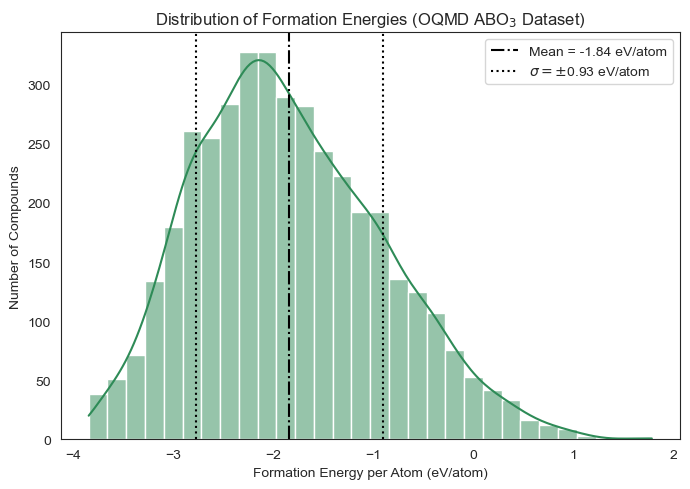

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
# Set the style of seaborn
sns.set_style(style="white")

# Calculate stats
mean_fe = df_oqmd["Formation energy [eV/atom]"].mean()
std_fe = df_oqmd["Formation energy [eV/atom]"].std()

# Plot
plt.figure(figsize=(7, 5))
sns.histplot(df_oqmd["Formation energy [eV/atom]"], bins=30, kde=True, color="seagreen")

# Annotate mean and std
plt.axvline(mean_fe, color="black", linestyle="-.", linewidth=1.5, label=f"Mean = {mean_fe:.2f} eV/atom")
plt.axvline(mean_fe + std_fe, color="black", linestyle=":", linewidth=1.5, label=f"$  \sigma = \pm ${std_fe:.2f} eV/atom")
plt.axvline(mean_fe - std_fe, color="black", linestyle=":", linewidth=1.5)

# Labels and title
plt.xlabel("Formation Energy per Atom (eV/atom)")
plt.ylabel("Number of Compounds")
plt.title("Distribution of Formation Energies (OQMD ABO$_3$ Dataset)")
plt.legend()
plt.tight_layout()
plt.show()


Q3 - Comparing data sets (32 points)
It is often useful to compare similar datasets to check them against each other. The simplest form of the perovskite crystal structure has formula ABO3, and such compounds are present in both the dataset you queried from the Materials Project in Q1 and the OQMD data you downloaded from figshare in Q2.

1. Identify the subset of formulas that are present in both the Materials Project dataset and OQMD dataset (hint: look at the Python built-in set object). How many formulas are there? (10 points)
2. Plot the distribution of the formation energies per atom of this subset of formulas for (a) the Materials Project dataset, and (b) the OQMD data, overlaying the two distributions on top of each other. Annotate your plot with the mean and standard deviation for each data set. (10 points)
3. Perform a hypothesis test at the 95% level to determine if there is a significant difference between the formation energies reported in the Materials Project and the OQMD dataset (hint: check out the scipy.stats.ttest_ind method). Discuss your findings, including providing any possible explanations for any discrepancy between the two datasets. (12 points)

1. Identify the subset of formulas that are present in both the Materials Project dataset and OQMD dataset (hint: look at the Python built-in set object). How many formulas are there? (10 points)

In [ ]:
#Get unique formulas from each dataset
unique_oqmd = df_oqmd["Chemical formula"].unique()
unique_abo3 = df_abo3["formula_pretty"].unique()
#Find the intersection of the two sets
common_formulas = set(unique_oqmd).intersection(set(unique_abo3))
#Count the number of common formulas
num_common_formulas = len(common_formulas)
print(f"Number of common formulas between OQMD and ABO3: {num_common_formulas}")

#Find the common formulas in both datasets
common_formulas_list = list(common_formulas)
# Create a DataFrame from the common formulas
common_formulas_df = pd.DataFrame(common_formulas_list, columns=["Common Formula"])
# Display the DataFrame
common_formulas_df.reset_index(drop=True, inplace=True)
common_formulas_df


Number of common formulas between OQMD and ABO3: 833


,Common Formula
0,YAlO3
1,NdZrO3
2,DyLuO3
3,TbInO3
4,InRhO3
...,...
828,TlCoO3
829,AcVO3
830,HfMgO3
831,LiOsO3


2. Plot the distribution of the formation energies per atom of this subset of formulas for (a) the Materials Project dataset, and (b) the OQMD data, overlaying the two distributions on top of each other. Annotate your plot with the mean and standard deviation for each data set. (10 points)

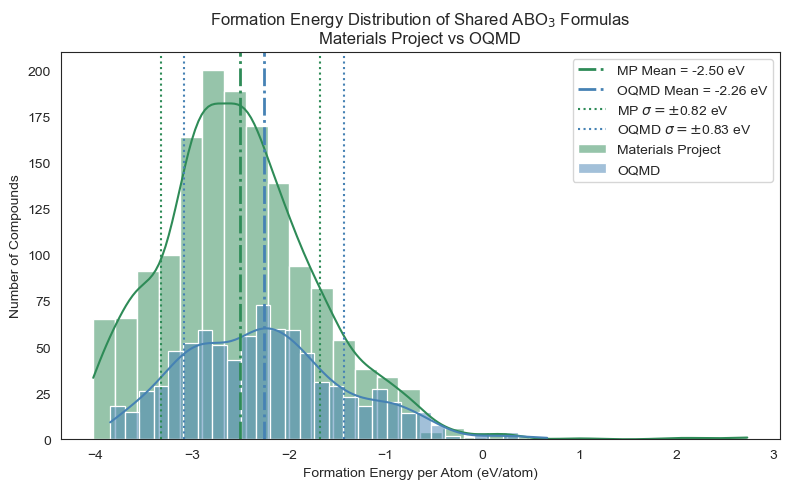

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

#Get shared formulas for each dataset
mp_shared=df_abo3[df_abo3["formula_pretty"].isin(common_formulas)].copy()
oqmd_shared=df_oqmd[df_oqmd["Chemical formula"].isin(common_formulas)].copy()

#calculate mean and std
mp_mean=mp_shared["formation_energy_per_atom"].mean()
mp_std=mp_shared["formation_energy_per_atom"].std()

oqmd_mean=oqmd_shared["Formation energy [eV/atom]"].mean()
oqmd_std=oqmd_shared["Formation energy [eV/atom]"].std()

#plot overlaied histograms
plt.figure(figsize=(8, 5))

sns.histplot(mp_shared["formation_energy_per_atom"], bins=30, color="seagreen", label="Materials Project", kde=True,   alpha=0.5)
sns.histplot(oqmd_shared["Formation energy [eV/atom]"], bins=30, color="steelblue", label="OQMD", kde=True,  alpha=0.5)

#add mean and std
plt.axvline(mp_mean, color="seagreen", linestyle="-.", linewidth=2, label=f"MP Mean = {mp_mean:.2f} eV")
plt.axvline(oqmd_mean, color="steelblue", linestyle="-.", linewidth=2, label=f"OQMD Mean = {oqmd_mean:.2f} eV")

plt.axvline(mp_mean + mp_std, color="seagreen", linestyle=":", linewidth=1.5, label=f"MP $  \sigma = \pm ${mp_std:.2f} eV") 
plt.axvline(mp_mean - mp_std, color="seagreen", linestyle=":", linewidth=1.5)

plt.axvline(oqmd_mean + oqmd_std, color="steelblue", linestyle=":", linewidth=1.5, label=f"OQMD $  \sigma = \pm ${oqmd_std:.2f} eV")
plt.axvline(oqmd_mean - oqmd_std, color="steelblue", linestyle=":", linewidth=1.5)

#Add label etc
plt.xlabel("Formation Energy per Atom (eV/atom)")
plt.ylabel("Number of Compounds")
plt.title("Formation Energy Distribution of Shared ABO$_3$ Formulas\nMaterials Project vs OQMD")
plt.legend()
plt.tight_layout()
plt.show()


3. Perform a hypothesis test at the 95% level to determine if there is a significant difference between the formation energies reported in the Materials Project and the OQMD dataset (hint: check out the scipy.stats.ttest_ind method). Discuss your findings, including providing any possible explanations for any discrepancy between the two datasets. (12 points)


In [16]:
from scipy.stats import ttest_ind
mp_values = mp_shared["formation_energy_per_atom"]
oqmd_values = oqmd_shared["Formation energy [eV/atom]"]

# Perform the t-test
t_stat, p_val = ttest_ind(mp_values, oqmd_values, equal_var=False,nan_policy='propagate',alternative='two-sided')

print(f"T-statistic: {t_stat:}")
print(f"P-value: {p_val:}")

T-statistic: -6.855498451773519
P-value: 9.92488909102288e-12



- Overall, this Welch's two-sample t-test was conducted to compare the formation energies of ABO3 compounds between the Materials Project and OQMD datasets. The resulting t-statistic was -6.86 (negative sign means the mean formation energy in MP is lower than that in OQMD), with a p-value of 9.92 e -12, which is well below the 0.05 threshold. Therefore, we reject the null hypothesis and conclude that there is a statistically significant difference between the two datasets.

    **Possible reasons for the difference:**
- Both MP and OQMD use density functional theory (DFT), but they don't necessarily use the same setup. MP mostly uses the GGA-PBE functional with PAW pseudopotentials, while OQMD uses GGA(PBE) or PW91 and may use slightly different pseudopotentials or settings.
- Formation energy is calculated relative to the elemental reference phase. If the reference states differ slightly between MP and OQMD, even if both use DFT, the calculated formation energy will shift. 
- MP is designed for materials discovery with an emphasis on stability and synthesis likelihood, so they tend to focus on known structures. While OQMD is built for high-throughput exploration, and includes many hypothetical or less optimized structures, possibly increasing error margins. 
- MP performs spin-polarized calculations and often attempts to model magnetic ground states while OQMD typically assumes ferromagnetic ordering or may ignore magnetism for speed. But since magnetism affects total energy, inconsistent treatment can lead to discrepancies.
- Difference in structure relaxation protocols also influence formation energy. MP relaxes all materials fully but OQMD sometimes starts with idealized or fixed strcutres for high-throughput screening. Since formation energy depends on total energy, and total energy is structure-sensitive, difference in relaxation directly affect formation energies. 

    **Despite these differences, both datasets are valuable and generally consistent in trends, even if the absolute values differ.**